In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# Opening cleaned PAROS dataset

In [11]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))


Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


# Standardize Reporting

In [12]:
def report_results(model_output, model_name="Model"):
    """
    Standardizes the reporting style for all versions.
    Uses .copy() and .loc to avoid ChainedAssignmentErrors.
    """
    # 1. Use .copy() to ensure 'summary' is an independent DataFrame
    summary = model_output.summary2().tables[1].copy()
    
    # 2. Use .loc[row_indexer, column_indexer] for explicit assignment
    summary.loc[:, 'OR'] = np.exp(summary['Coef.'])
    summary.loc[:, 'Lower_95_CI'] = np.exp(summary['Coef.'] - 1.96 * summary['Std.Err.'])
    summary.loc[:, 'Upper_95_CI'] = np.exp(summary['Coef.'] + 1.96 * summary['Std.Err.'])
    
    # 3. Clean and Rename Columns
    final_table = summary[['OR', 'Lower_95_CI', 'Upper_95_CI', 'P>|z|']]
    final_table.columns = ['Odds Ratio', 'Lower 95% CI', 'Upper 95% CI', 'p-value']
    
    print(f"\n{'='*20} {model_name} Results {'='*20}")
    return final_table

# Define Binary Outcome (Survival to 30 Days)


In [13]:
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']
df.loc[:, 'Outcome_String'] = df[outcome_cols].astype(str).agg(' '.join, axis=1)
survival_regex = r'Discharged Alive|Remains in hospital at 30th day'
df.loc[:, 'Survival_Binary'] = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True).astype(int)

# Define Primary Predictor (Bystander AED applied)
- We map any variation of 'Yes' or '1' to 1, and everything else to 0

In [14]:
aed_col = 'Bystander AED applied'
df.loc[:, 'AED_Applied_Binary'] = df[aed_col].astype(str).str.contains('Yes|Applied|1', case=False, na=False).astype(int)

# Fit the Model
- Constant (Intercept) represents the 'No AED' baseline odds

In [15]:
X = sm.add_constant(df['AED_Applied_Binary'])
y = df['Survival_Binary']

model_v1 = sm.Logit(y, X).fit()

Optimization terminated successfully.
         Current function value: 0.456657
         Iterations 5


# Extract Results and Convert to Odds Ratios (OR)

In [16]:
results = model_v1.summary2().tables[1]
results.loc[:, 'OR'] = np.exp(results['Coef.'])
results.loc[:, 'Lower_95_CI'] = np.exp(results['Coef.'] - 1.96 * results['Std.Err.'])
results.loc[:, 'Upper_95_CI'] = np.exp(results['Coef.'] + 1.96 * results['Std.Err.'])

# Output

In [17]:
display(report_results(model_v1, "Version 1: Baseline"))


==================== Version 1: Baseline Results ====================


,Odds Ratio,Lower 95% CI,Upper 95% CI,p-value
const,0.200372,0.177806,0.225803,3.001129e-153
AED_Applied_Binary,1.663571,1.050548,2.634307,2.998627e-02


/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_63470/641854376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=groups, y=survival_rates, palette='viridis')


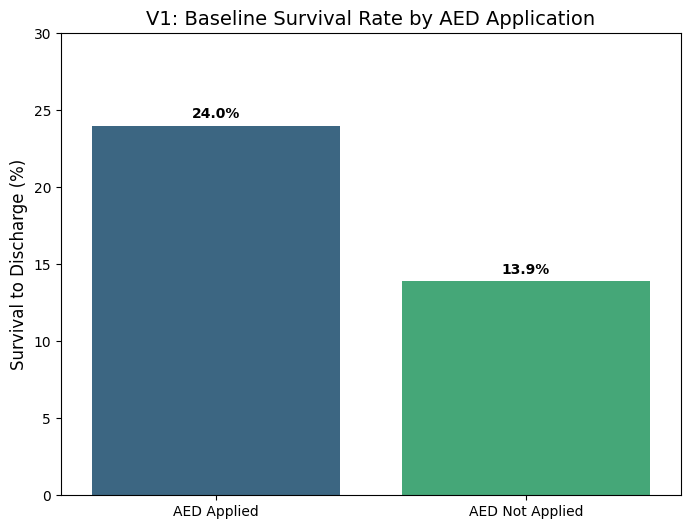

In [18]:
# Data from your Table 1
groups = ['AED Applied', 'AED Not Applied']
survival_rates = [24.0, 13.9] # Percentages

plt.figure(figsize=(8, 6))
sns.barplot(x=groups, y=survival_rates, palette='viridis')

plt.title('V1: Baseline Survival Rate by AED Application', fontsize=14)
plt.ylabel('Survival to Discharge (%)', fontsize=12)
plt.ylim(0, 30)

# Add labels on top of bars
for i, v in enumerate(survival_rates):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.show()